# Exploratory Data Analysis

This notebook exists to answer one design question: **what is worth predicting in this data?**

The obvious target — tomorrow's return — is the one almost every stock-prediction project
picks, and the one that has no signal in it. Rather than assert that, the analysis below
measures it, and measures the alternative alongside. The result decides which experiment is
the headline and which is filed as a negative control.

Four questions, in order:

1. What does the panel actually contain?
2. How are daily returns distributed?
3. Is volatility stable over time, or does it cluster?
4. **Which of the two — return or volatility — carries memory of its own past?**

In [4]:
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd

from src import config
from src.data.cache import get_prices
from src.features.technical import log_returns, realized_volatility
from src.viz import plots

plots.set_style()

prices = get_prices()
prices["log_return"] = log_returns(prices)

print(f"{len(prices):,} rows   {prices['ticker'].nunique()} tickers   "
      f"{prices['date'].min().date()} to {prices['date'].max().date()}")

1,799,961 rows   231 tickers   1990-01-02 to 2026-08-31


## 1. What the panel contains

Two things matter for modelling. First, the universe is **not** constant through time: fewer
companies are observable in 1990 than in 2020, so any pooled model sees a widening panel.
Second, histories are uneven, which is why the cleaning step drops anything under three years.

There is a limitation visible here that no amount of care can fix: every ticker in this dataset
survived to 2026. Companies that were delisted, went bankrupt or were acquired are absent. Any
model trained on this panel will look better than it would have in real time. That is
**survivorship bias**, and the honest response is to state it rather than to hide it.

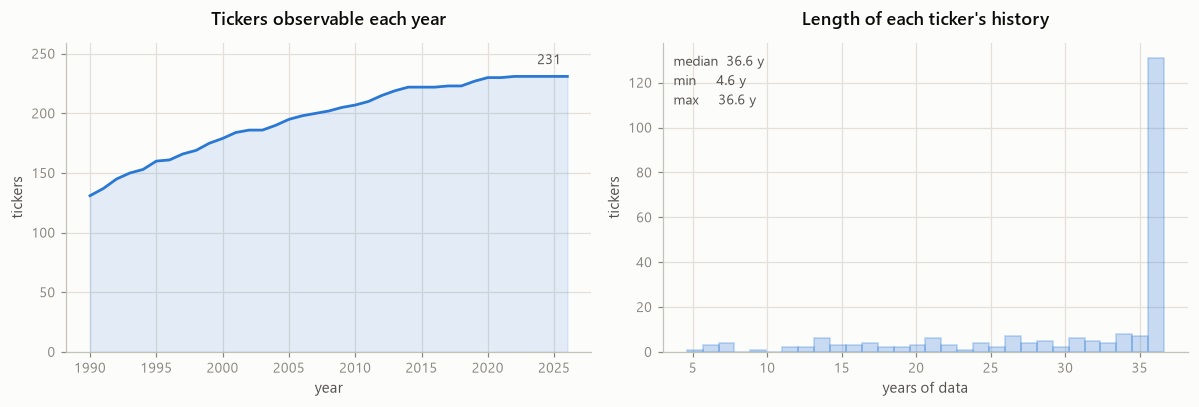

In [5]:
fig = plots.plot_universe_coverage(prices)
plots.save_figure(fig, "01_universe_coverage");

## 2. Returns are not normally distributed

Ordinary least squares does not require normally distributed errors to be unbiased, but nearly
every convenient thing said about it — standard errors, confidence intervals, significance
tests — leans on approximate normality. So it is worth knowing how far from normal the raw
material is before building on it.

The y-axis below is logarithmic on purpose. On a linear axis the two curves look
indistinguishable, because all of the disagreement lives in tails that are thousands of times
shorter than the peak.

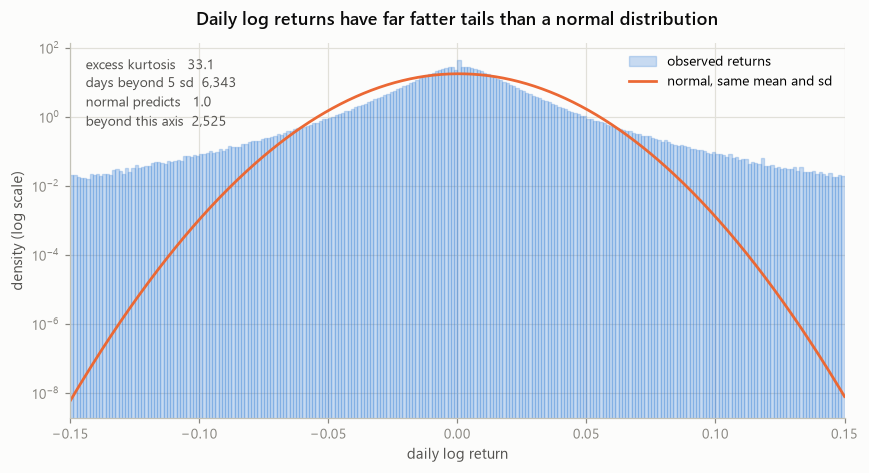

In [6]:
fig = plots.plot_return_distribution(prices["log_return"])
plots.save_figure(fig, "02_return_distribution");

In [4]:
from math import erfc, sqrt

r = prices["log_return"].dropna()
mu, sd = r.mean(), r.std()

tails = pd.DataFrame({
    "observed": [int((r.sub(mu).abs() > k * sd).sum()) for k in (3, 4, 5, 6)],
    "expected if normal": [len(r) * erfc(k / sqrt(2)) for k in (3, 4, 5, 6)],
}, index=pd.Index([f"|r| > {k} sd" for k in (3, 4, 5, 6)], name=""))
tails["ratio"] = tails["observed"] / tails["expected if normal"]
tails.style.format({"observed": "{:,.0f}", "expected if normal": "{:,.1f}", "ratio": "{:,.0f}x"})

,observed,expected if normal,ratio
,,,
|r| > 3 sd,"29,030","4,858.9",6x
|r| > 4 sd,"12,593",114.0,110x
|r| > 5 sd,"6,343",1.0,"6,148x"
|r| > 6 sd,"3,496",0.0,"984,461x"


A normal distribution predicts roughly **one** five-sigma day across all 1.8 million
observations. The data contains several thousand. Six-sigma days should essentially never
happen; there are thousands of those too.

This is not a data error — it is the single most reproducible fact in empirical finance. It
matters here in a specific way: models fitted by least squares are sensitive to extreme
observations, because squaring the error gives a 6-sigma day 36 times the weight of a 1-sigma
day. Later phases will report metrics that are robust to this, not only R².

## 3. Volatility arrives in bursts

Below, the market aggregate: the cross-sectional median daily return across all tickers, and
its 21-day realised volatility.

Notice what the top panel does **not** look like. If returns were independent draws from a
fixed distribution, the band would have constant width. Instead it visibly breathes — long calm
stretches interrupted by violent clusters. Turbulent days arrive next to other turbulent days.

median annualised volatility: 11.7%
peak: 102.5% on 2020-04-06


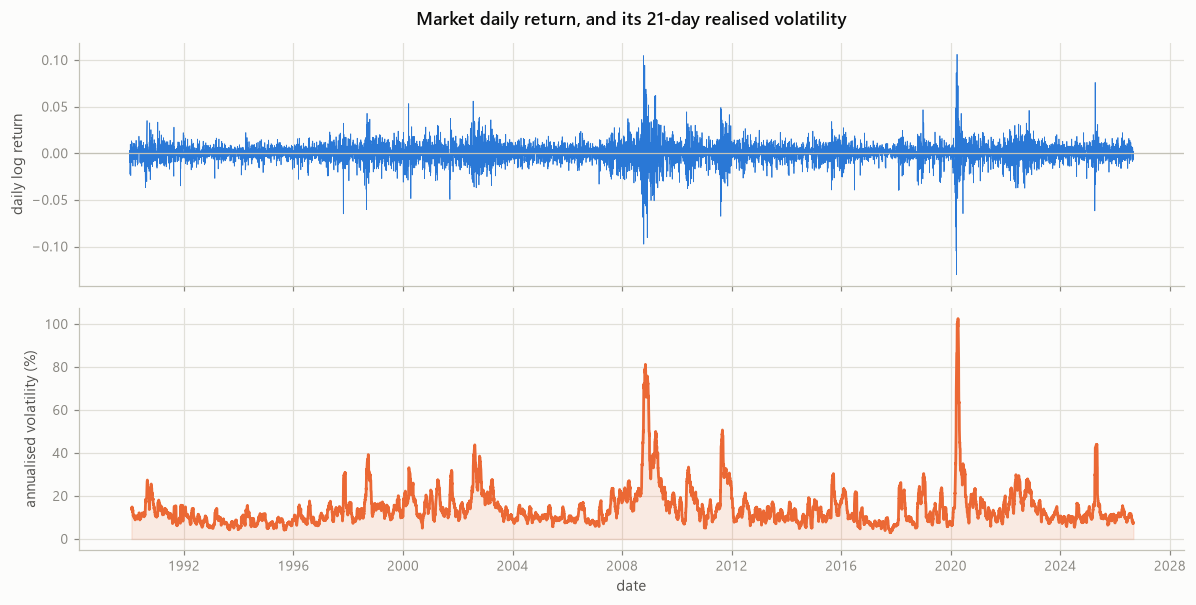

In [5]:
market = prices.groupby("date", observed=True)["log_return"].median()
market_vol = market.rolling(config.HORIZON, min_periods=config.HORIZON).std() * np.sqrt(
    config.TRADING_DAYS_PER_YEAR
)

fig = plots.plot_volatility_clustering(market.index, market.to_numpy(), market_vol.to_numpy())
plots.save_figure(fig, "03_volatility_clustering")

print(f"median annualised volatility: {market_vol.median():.1%}")
print(f"peak: {market_vol.max():.1%} on {market_vol.idxmax().date()}")

## 4. The chart this project rests on

Volatility clustering suggests that the *magnitude* of returns carries information about the
future, even if their *direction* does not. The autocorrelation function tests that directly:
it measures how strongly a series correlates with its own past at each lag.

Both curves are computed per ticker and then averaged. Concatenating all 231 series and running
one ACF would splice each company's last observation onto the next company's first, which
would quietly corrupt every lag.

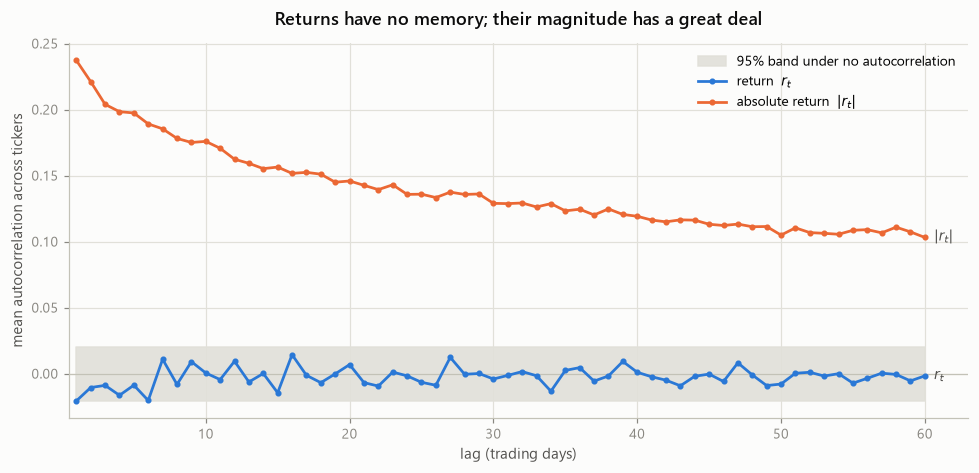

In [6]:
MAX_LAG = 60
lags = np.arange(1, MAX_LAG + 1)

acf_return = plots.mean_acf(prices["log_return"], prices["ticker"], MAX_LAG)
acf_abs_return = plots.mean_acf(prices["log_return"], prices["ticker"], MAX_LAG, absolute=True)

median_history = int(prices.groupby("ticker", observed=True).size().median())

fig = plots.plot_acf_comparison(lags, acf_return, acf_abs_return, median_history)
plots.save_figure(fig, "04_acf_return_vs_absolute");

In [7]:
band = 1.96 / np.sqrt(median_history)

print(f"95% band under no autocorrelation:  +/-{band:.4f}\n")
print(f"  largest |ACF| of returns, lags 1-60 :  {np.abs(acf_return).max():.4f}")
print(f"  smallest ACF of |returns|, lags 1-60:  {acf_abs_return.min():.4f}\n")
print(f"  lags where returns exceed the band  :  {(np.abs(acf_return) > band).sum():>2} of {MAX_LAG}")
print(f"  lags where |returns| exceed the band:  {(acf_abs_return > band).sum():>2} of {MAX_LAG}")

95% band under no autocorrelation:  +/-0.0204

  largest |ACF| of returns, lags 1-60 :  0.0206
  smallest ACF of |returns|, lags 1-60:  0.1032

  lags where returns exceed the band  :   1 of 60
  lags where |returns| exceed the band:  60 of 60


That is the result the whole project is organised around.

Returns wander inside the noise band at every lag — the one exception is lag 1, and it barely
clears it. Absolute returns sit **above** the band at all sixty lags, and are still there three
months out. Whatever drives the size of price moves has a long memory; whatever drives their
sign does not.

## 5. Putting a number on the asymmetry

The ACF shows the shape. The table below shows the stakes, in the units the models will
actually be scored in. Both rows ask the same question — *how much of the next 21 days can be
explained by what we already know?* — of two different targets.

In [8]:
vol_21 = realized_volatility(prices["log_return"], prices["ticker"], config.HORIZON)
future_vol = vol_21.groupby(prices["ticker"], observed=True).shift(-config.HORIZON)
future_return = prices["log_return"].groupby(prices["ticker"], observed=True).shift(-1)


def correlation(a: pd.Series, b: pd.Series) -> float:
    usable = a.notna() & b.notna()
    return float(np.corrcoef(a[usable], b[usable])[0, 1])


corr_vol = correlation(np.log(vol_21), np.log(future_vol))
corr_ret = correlation(prices["log_return"], future_return)

comparison = pd.DataFrame(
    {
        "predictor": ["past 21-day volatility", "today's return"],
        "target": ["next 21-day volatility", "tomorrow's return"],
        "correlation": [corr_vol, corr_ret],
        "R2": [corr_vol**2, corr_ret**2],
    }
).set_index("predictor")
comparison.style.format({"correlation": "{:+.4f}", "R2": "{:.5f}"})

,target,correlation,R2
predictor,,,
past 21-day volatility,next 21-day volatility,+0.6917,0.47848
today's return,tomorrow's return,-0.0159,0.00025


The simplest imaginable volatility forecast — *next month will look like last month* —
explains close to half the variance. The equivalent return forecast explains essentially
nothing: the two R² values differ by roughly three orders of magnitude.

Note that the volatility number is also the **baseline to beat**. A model that achieves R² 0.45
on this target has not found signal; it has failed to match a one-line rule. Phase 3 builds
that baseline explicitly, before any model is fitted.

## What this settles

| Finding | Consequence for the design |
|---|---|
| Returns show no usable autocorrelation | Predicting returns is **Experiment 2**, a negative control — reported honestly, not as the headline |
| Absolute returns stay autocorrelated for 60+ days | Predicting volatility is **Experiment 1**, the main case |
| Persistence alone gives R² ≈ 0.48 on volatility | The volatility baseline is strong; beating it is the real bar |
| Excess kurtosis 33; thousands of 5-sigma days | Least squares will be strained by outliers; report robust metrics alongside R² |
| Volatility is right-skewed and strictly positive | Model **log** volatility, which is closer to the symmetry OLS assumes |
| Universe grows over time; all tickers survive to 2026 | Survivorship bias is unfixable here and belongs in the README's limitations |

One more consequence, easy to miss. A 21-day target built at date *t* overlaps the target built
at *t+1* by twenty days. Neighbouring rows are therefore far from independent — which is
exactly why the walk-forward split in Phase 3 discards a 21-day **embargo** between training
and test folds rather than cutting them flush.

Next: **Phase 2**, building leakage-free features and the four targets.